In [1]:
import pandas as pd

df = pd.read_csv("books_raw.csv")

print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  100 non-null    int64
 1   title       100 non-null    str  
 2   price       100 non-null    str  
 3   rating      100 non-null    str  
dtypes: int64(1), str(3)
memory usage: 8.8 KB
None
   Unnamed: 0                                  title   price rating
0           0                   A Light in the Attic  £51.77  Three
1           1                     Tipping the Velvet  £53.74    One
2           2                             Soumission  £50.10    One
3           3                          Sharp Objects  £47.82   Four
4           4  Sapiens: A Brief History of Humankind  £54.23   Five


In [2]:
# Remove the currency symbol so price can be converted from text to a numeric value.
df["price"] = df["price"].str.replace("£", "", regex=False).astype(float)

# Convert word-based ratings into numeric values so we can calculate and compare them.
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating_num"] = df["rating"].map(rating_map)

print(df.head())
print(df.dtypes)

   Unnamed: 0                                  title  price rating  rating_num
0           0                   A Light in the Attic  51.77  Three           3
1           1                     Tipping the Velvet  53.74    One           1
2           2                             Soumission  50.10    One           1
3           3                          Sharp Objects  47.82   Four           4
4           4  Sapiens: A Brief History of Humankind  54.23   Five           5
Unnamed: 0      int64
title             str
price         float64
rating            str
rating_num      int64
dtype: object


In [3]:
# Remove extra whitespace from book titles so identical titles match correctly.
df["title"] = df["title"].str.strip()

# Remove duplicate books that may have appeared because of pagination overlap.
df = df.drop_duplicates(subset="title")

# Remove the original CSV index column because it is not useful for analysis.
df = df.drop(columns=["Unnamed: 0"])

print(df.info())
print(f"Number of books after cleaning: {len(df)}")

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       100 non-null    str    
 1   price       100 non-null    float64
 2   rating      100 non-null    str    
 3   rating_num  100 non-null    int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 8.1 KB
None
Number of books after cleaning: 100


In [4]:
# Question 1: Do higher-rated books cost more?
avg_price_by_rating = df.groupby("rating_num")["price"].mean()

print("\nAverage price by rating:")
print(avg_price_by_rating)


# Question 2: What is the average and price range for each rating?
price_summary = df.groupby("rating_num")["price"].agg(["mean", "min", "max"])

print("\nPrice summary by rating:")
print(price_summary)



Average price by rating:
rating_num
1    35.519545
2    35.909474
3    36.839091
4    33.981667
5    30.012105
Name: price, dtype: float64

Price summary by rating:
                 mean    min    max
rating_num                         
1           35.519545  12.84  56.41
2           35.909474  13.99  56.40
3           36.839091  10.16  57.31
4           33.981667  14.02  58.11
5           30.012105  13.34  54.23


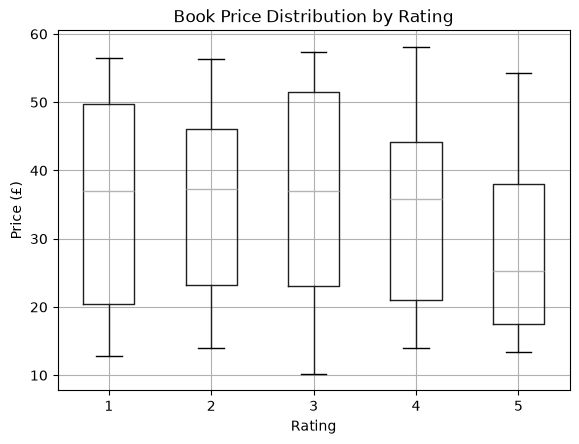

In [5]:
import matplotlib.pyplot as plt

# Compare the distribution of book prices across each rating.
df.boxplot(column="price", by="rating_num")

plt.title("Book Price Distribution by Rating")
plt.suptitle("")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.show()

In [6]:
# Save the cleaned dataset so it can be reused for future analysis without repeating the cleaning process.
df.to_csv("books_cleaned.csv", index=False)

print(f"Saved {len(df)} cleaned books to books_cleaned.csv")

Saved 100 cleaned books to books_cleaned.csv
